# Configuration

ne =  2.1463557810023133
no =  2.229080611296175
eps_e =  4.606843138642049
eps_o =  4.96880037165653
ne =  [2.315266894439615, 2.313957321796871, 2.312662530344611, 2.3113822837204636, 2.3101163504888222, 2.3088645040136186, 2.3076265223350227, 2.3064021880499284, 2.305191288196083, 2.303993614139739, 2.302808961466697, 2.301637129876632, 2.300477923080568, 2.2993311487014148, 2.298196618177445, 2.2970741466686144, 2.2959635529656315, 2.2948646594016773, 2.2937772917666903, 2.2927012792241257, 2.2916364542301104, 2.2905826524549076, 2.2895397127066204, 2.2885074768570584, 2.2874857897696907, 2.2864744992296258, 2.285473455875547, 2.284482513133539, 2.283501527152746, 2.2825303567428055, 2.281568863312995, 2.2806169108130394, 2.2796743656755325, 2.2787410967599078, 2.277816975297923, 2.2769018748406067, 2.2759956712066187, 2.275098242431982, 2.2742094687211467, 2.27332923239934, 2.2724574178661685, 2.2715939115504264, 2.2707386018660864, 2.269891379169422, 2.269052135717236, 2.26822076

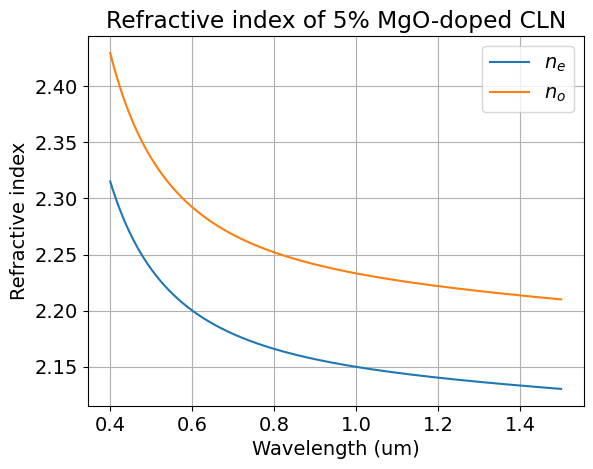

In [1]:
import numpy as np  
# 5% Mg doped CLN
def get_n2i(lam, T, a, b): 
    lam = lam *1e6 # convert to um
    f = get_f(T)
    b = [bb* f for bb in b]
    n2 = a[0] + b[0] + (a[1]+b[1])/(lam**2 - (a[2]+b[2])**2) + (a[3]+b[3])/(lam**2 - (a[4]**2)) - a[5]*lam**2
    return n2

ae = [05.756, 0.0983, 0.2020,189.32,12.52, 1.32e-2 ]
ao = [5.653, 0.1185, 0.2091, 89.61, 10.85, 1.97e-2]
be = [2.86e-6, 4.7e-8, 6.113e-8, 1.516e-8]
bo = [7.941e-7, 3.134e-8, -4.641e-9, -2.188e-60]

def get_f(T):
    return (T-24.5)*(T+570.82)

lam0 = 1064e-9
n2e = get_n2i(lam0, 20, ae, be)
n2o = get_n2i(lam0, 20, ao, bo)

eps_e = n2e
eps_o = n2o

ne = np.sqrt(eps_e)
no = np.sqrt(eps_o)
print("ne = ", ne)
print("no = ", no)
print("eps_e = ", eps_e)
print("eps_o = ", eps_o)

nes =[]
nos = []
lams = np.linspace(400e-9, 1500e-9, 1000)
for lam in lams:
    n2e = get_n2i(lam, 20, ae, be)
    n2o = get_n2i(lam, 20, ao, bo)
    ne = np.sqrt(n2e)
    no = np.sqrt(n2o)

    nes.append(ne)
    nos.append(no)

import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 14  
plt.plot(lams*1e6, nes, label='$n_e$')
plt.plot(lams*1e6, nos, label='$n_o$')
print("ne = ", nes, "no = ", nos)
plt.xlabel('Wavelength (um)')
plt.ylabel('Refractive index')
plt.title('Refractive index of 5% MgO-doped CLN')
plt.grid()
plt.legend()

In [13]:
root = r"/zhome/2f/7/202918/phc_nzi"
src = r"/zhome/2f/7/202918/phc_nzi/src"
import sys
sys.path.append(root)
sys.path.append(src)

## Define the materials
from src.photonic_crystal_maker import (Material, Geometry, PhotonicCrystal, 
                                        ScriptParam, ScriptParamVector3, BaseDielectricDistribution,
                                        HexagonalLattice)
import meep as mp
from src.mpb_configurator import *
from src.mpi_differential_evolution import MPIdeOptimizator
from src.simulation_handler import LSFJobConfiguration, MPBDataOptions, Simulation
from src.optimization_data_analyzer import OptimizationDataAnalyzer
from src.simulation_viewer import SimulationViewer
from src.lsf_sweeper import LSFSweeper
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
plt.rcParams["font.size"] = 14


eps = (eps_o, eps_o, eps_e)

LN = Material(epsilon = eps)
print("Epsilon of LiNbO3: ", LN.to_scheme())
air = Material(epsilon = 1)
## Simulation Name: 
name = "LiNb_C4v_diatomic"

## Define the geometry
radius1 = ScriptParam("r1", 0.3)
radius2 = ScriptParam("r2", 0.2)
height_supercell = 3
height_slab = ScriptParam("h", 0.4)
slab_block_size = ScriptParamVector3(1e20, 1e20, "h", z_def = 0.4)

## Define the lattice

lattice_2D = SquareLattice()
lattice_slab = SquareLattice(supercell_height= 4)

k_points = lattice_2D.get_k_points_around_gamma(0.5)
k_points_slab = lattice_slab.get_high_symmetry_k_points(centered_in_gamma=False)



center = mp.Vector3(0,0,0)


geom_2D = BaseDielectricDistribution(eps_bulk = eps).make_C4v_diatomic_A()
geom_slab = BaseDielectricDistribution(eps_bulk = eps, height_slab=0.5, cz_sphere=0.5/2).make_C4v_diatomic_A_sphere()


photonic_crystal_2D = PhotonicCrystal(lattice=lattice_2D, atoms=geom_2D)
photonic_crystal_slab = PhotonicCrystal(lattice=lattice_slab, atoms=geom_slab)

## Define the simulation
configuration_options_single_2D = dict(
    resolution = 32, 
    num_bands=10,
    k_points=k_points["k_points_values"],
    k_points_interpolation_factor = 20,
    extra_runner_command = "(output-at-kpoint (vector3 0 0 0) fix-efield-phase output-efield)",
)

configuration_options_single_slab = dict(
    resolution = 32, 
    num_bands=30,
    k_points=k_points_slab["k_points_values"],
    k_points_interpolation_factor = 10,
    extra_runner_command = "(output-at-kpoint (vector3 0 0 0) fix-efield-phase output-efield)",
)

configuration_options_optimization = dict(
    resolution = 32, 
    num_bands=30,
    k_points = [mp.Vector3(0,0,0)],
    
)

configuration_options_sweep = dict( 
    resolution = 32,
    num_bands=30,
    k_points=[mp.Vector3(0,0,0)],
)


mpb_configuration_2D = MPBSchemeConfigurator(photonic_crystal_2D, ["te", "tm"], **configuration_options_single_2D)
mpb_configuration_2D_opt = MPBSchemeConfigurator(photonic_crystal_2D, ["te"], **configuration_options_optimization)
mpb_configuration_2D_sweep = MPBSchemeConfigurator(photonic_crystal_2D, ["te"], **configuration_options_sweep)

mpb_configuration_slab = MPBSchemeConfigurator(photonic_crystal_slab, [None], **configuration_options_single_slab)
mpb_configuration_slab_opt = MPBSchemeConfigurator(photonic_crystal_slab, [None], **configuration_options_optimization)
mpb_configuration_slab_sweep = MPBSchemeConfigurator(photonic_crystal_slab, [None], **configuration_options_sweep)

script_2D = mpb_configuration_2D.get_scheme_config(join_newline=True)
script_2D_opt = mpb_configuration_2D_opt.get_scheme_config(join_newline=True)
script_2D_sweep = mpb_configuration_2D_sweep.get_scheme_config(join_newline=True)

script_slab = mpb_configuration_slab.get_scheme_config(join_newline=True)
script_slab_opt = mpb_configuration_slab_opt.get_scheme_config(join_newline=True)
script_slab_sweep = mpb_configuration_slab_sweep.get_scheme_config(join_newline=True)




name_2D = name  + "_2D"
name_2D_opt = name + "_2D_opt"
name_2D_sweep = name + "_2D_sweep"
name_2D_optimized = name + "_2D_optimized"  
name_slab = name + "_slab"
name_slab_opt = name + "_slab_opt"
name_slab_sweep = name + "_slab_sweep"
name_slab_optimized = name + "_slab_optimized"

data_rooth = "/work3/s232699/phc_nzi/LiNb/ooe_te"


simulation_2D = Simulation(
    simulation_name=name_2D,
    script = script_2D,
    directory= os.path.join(data_rooth, name_2D)
    )

simulation_2D_opt = Simulation(
    simulation_name=name_2D_opt,
    script = script_2D_opt,
    directory= os.path.join(data_rooth, name_2D_opt)
    )

simulation_2D_sweep = Simulation(
    simulation_name=name_2D_sweep,
    script = script_2D_sweep,
    directory= os.path.join(data_rooth, name_2D_sweep)
    )

simulation_2D_optimized = Simulation(
    simulation_name=name_2D_optimized,
    script = script_2D,
    directory= os.path.join(data_rooth, name_2D_optimized)
    )



simulation_slab = Simulation(
    simulation_name=name_slab,
    script = script_slab,
    directory= os.path.join(data_rooth, name_slab)
    )


simulation_slab_opt = Simulation(
    simulation_name=name_slab_opt,
    script = script_slab_opt,
    directory= os.path.join(data_rooth, name_slab_opt)  
    )

simulation_slab_sweep = Simulation(
    simulation_name=name_slab_sweep,
    script = script_slab_sweep,
    directory= os.path.join(data_rooth, name_slab_sweep)  
    )

simulation_slab_optimized = Simulation(
    simulation_name=name_slab_optimized,
    script = script_slab,
    directory= os.path.join(data_rooth, name_slab_optimized)  
    )


numproc= 32
pop = numproc // 2
lsf_config = LSFJobConfiguration(num_processors=numproc, span_option="block", span_value=8, queue="fotonano")


Epsilon of LiNbO3:  (make dielectric-anisotropic (epsilon-diag (vector3 4.96880037165653 4.96880037165653 4.606843138642049)))
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 0.5)', '(define-param r1 0.1)', '(define-param cz_sphere 0.25)', '(define-param r2 0.2)']
simulation type: None
COMMANDS ['(define-param h 0.5)', '(define-param r1 0.1)', '(define-param cz_sphere 0.25)', '(define-param r2 0.2)']
simulation type: None
COMMANDS ['(define-param h 0.5)', '(define-param r1 0.1)', '(define-param cz_sphere 0.25)', '(define-param r2 0.2)']
simulation type: None


# 2D

## Unoptimized

2D simulation done
Epsilon data loaded; maximum value:  4.96880037165653


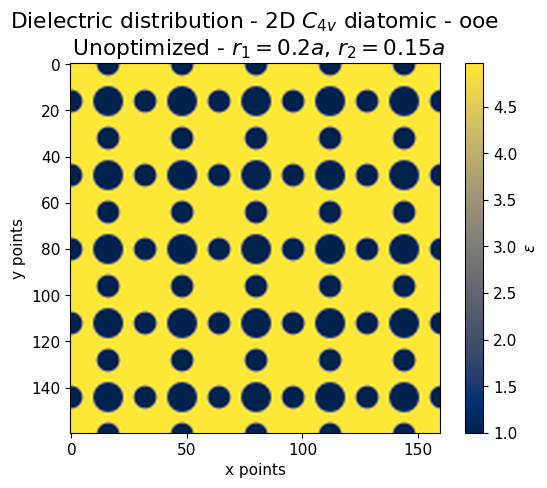

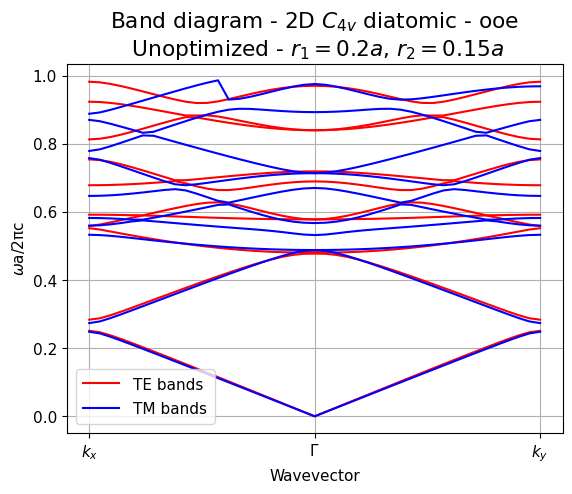

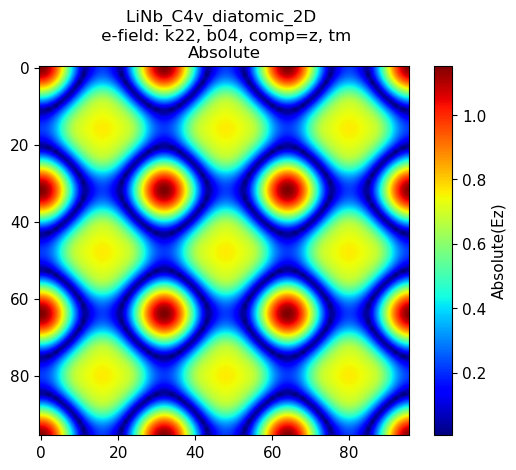

In [14]:
r2 = 0.15
r1 = 0.2
crystal_orientation = "ooe"
plt.rcParams['font.size'] = 13
#simulation_2D.run_hpc(mpb_command_line_params=dict(r1 = 0.2400, r2 = 0.2334), mpi = True)4
simulation_2D.run_hpc(mpb_command_line_params=dict(r1 = r1, r2 = r2), mpi = True)
print("2D simulation done")
viewer_2D = SimulationViewer(simulation_2D) 
opt = MPBDataOptions(rectify=True, periods= 5)
viewer_2D.figure()
viewer_2D.plot_epsilon_2d(conversion_options=opt)
eps = simulation_2D.load_and_convert_epsilon_data()
print("Epsilon data loaded; maximum value: ", eps.max())
plt.xlabel("x points")
plt.ylabel("y points")
data_line = f"$r_1={r1}a$, $r_2={r2}a$"
plt.title(f"Dielectric distribution - 2D $C_{{4v}}$ diatomic - {crystal_orientation} \n Unoptimized - " + data_line)
viewer_2D.show()


viewer_2D.plot_band_diagram("te", k_points_path=k_points, color = "red")
viewer_2D.plot_band_diagram("tm", k_points_path=k_points, color = "blue")
plt.ylabel("$\omega$a/2πc")
plt.title(f"Band diagram - 2D $C_{{4v}}$ diatomic - {crystal_orientation} \n Unoptimized - " + data_line)

viewer_2D.show()

viewer_2D.plot_field_2d(22, 4, "e", "z", "tm", False, np.abs) 


## Optimization

<Figure size 640x480 with 0 Axes>

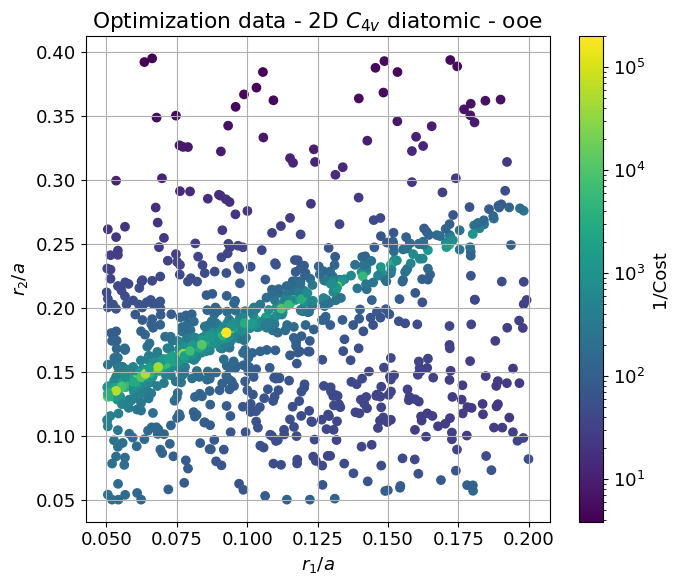

In [39]:
optimizer = MPIdeOptimizator(
        simulation_name=simulation_2D_opt.simulation_name,
        scheme_script=simulation_2D_opt.script, 
        maxiter=30,
        param_names=["r1", "r2"],
        param_bounds=[(0.05, 0.2), (0.05, 0.4)],
        polarization="tm",
        de_options={"strategy": "rand1bin", "popsize": pop},
        bands=[2,3,4],
        directory=os.path.join(data_rooth, simulation_2D_opt.simulation_name),
    )
# optimizer.erease_data_file()
# optimizer.submit_lsf_job(lsf_config)

analyzer = OptimizationDataAnalyzer(optimizer.data_file)
plt.figure()
analyzer.plot_raw_data(plot_inverse_cost=True, points_only=True, use_logscale=True)
plt.grid() 
plt.xlabel("$r_1/a$")
plt.ylabel("$r_2/a$") 
plt.title(f"Optimization data - 2D $C_{{4v}}$ diatomic - {crystal_orientation}")   
plt.show()

df = analyzer.get_points_above_treshold(100)




## Sweep 

In [17]:
# Sweep 2D 
# Instantiate the new sweeper
r1 = 0.10
print("r1: ", r1)
values = np.linspace(0.17, 0.2, 64, endpoint=True)
sweeper = LSFSweeper(simulation_2D_sweep.simulation_name + "_r2", directory=simulation_2D_sweep.directory + "_r2",
                     scheme_script=simulation_2D_sweep.script, 
                        param_name="r2", param_values=values,
                        polarization="te",
                        bands=[7,8, 9],
                        others_command_line_params={"r1": r1},
                       )

#Run the sweeper
sweeper.submit_lsf_job(lsf_config)

r1:  0.1
LSF job script written to: /work3/s232699/phc_nzi/LiNb/ooe_te/LiNb_C4v_diatomic_2D_sweep_r2/LiNb_C4v_diatomic_2D_sweep_r2.sh
Job submitted successfully. Submission output:
Job <24906992> is submitted to queue <fotonano>.

Waiting for job 24906992 to finish...
Job 24906992 status: PEND, elapsed time: 0 sec
Job 24906992 status: PEND, elapsed time: 10 sec
Job 24906992 status: RUN, elapsed time: 20 sec
Job 24906992 status: RUN, elapsed time: 30 sec
Job 24906992 status: RUN, elapsed time: 40 sec
Job 24906992 status: RUN, elapsed time: 50 sec
Job 24906992 status: RUN, elapsed time: 60 sec
Job 24906992 status: RUN, elapsed time: 70 sec
Job 24906992 status: RUN, elapsed time: 80 sec
Job 24906992 status: RUN, elapsed time: 90 sec
Job 24906992 status: RUN, elapsed time: 100 sec
Job 24906992 status: RUN, elapsed time: 110 sec
Job 24906992 status: RUN, elapsed time: 120 sec
Job 24906992 status: RUN, elapsed time: 130 sec
Job 24906992 status: RUN, elapsed time: 140 sec
Job 24906992 status:

'Job <24906992> is submitted to queue <fotonano>.\n'

r1 [nm]:  85.9668376
r2 [nm]:  171.9336752
a [nm]:  859.6683760000001
w_mpb:  0.807959
w_phy:  281.75982894736836
r2 [a]:  0.2
r1 [a]:  0.1


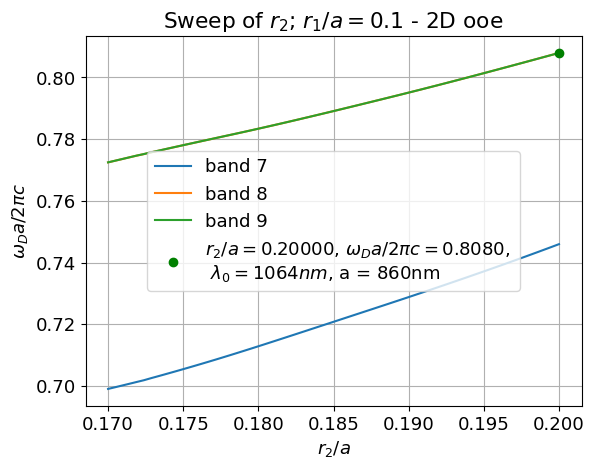

In [21]:
df = sweeper.load_results()
#display(df)
plt.figure()

plt.plot(df["r2"], df["band_7"], label="band 7")
plt.plot(df["r2"], df["band_8"], label="band 8")
plt.plot(df["r2"], df["band_9"], label="band 9")

plt.grid()
plt.xlabel("$r_2/a$")
plt.ylabel("$\omega_Da/2\pi c$")
ylim = plt.ylim()
idx_freq_dirac = np.argmin(np.abs(df["band_9"] - df["band_7"]))


r2 = df["r2"][idx_freq_dirac]
r1 = 0.1
w_mpb = df["band_8"][idx_freq_dirac]
a_phy = w_mpb*lam0
r1_phy = r1*a_phy
r2_phy = r2*a_phy
c0 = 299792458
w_phy = c0/lam0
print("r1 [nm]: ", r1_phy*1e9)
print("r2 [nm]: ", r2_phy*1e9)
print("a [nm]: ", a_phy*1e9)
print("w_mpb: ", w_mpb)
print("w_phy: ", w_phy*1e-12)
print("r2 [a]: ", r2)
print("r1 [a]: ", r1)




plt.plot(r2, w_mpb, "go", label = f"$r_2/a ={round(r2,5):0.5f}$, $\omega_Da/2\pi c = {w_mpb:0.4f}$, \n $\lambda_0 = {lam0*1e9:.0f}nm $, a = {a_phy*1e9:0.0f}nm") 
plt.legend()
plt.title(f"Sweep of $r_2$; $r_1/a = {r1:0.1f}$ - 2D {crystal_orientation}")
plt.show()

c0 = 299792458
r2 = 0.18810




## Optimized

2D simulation done


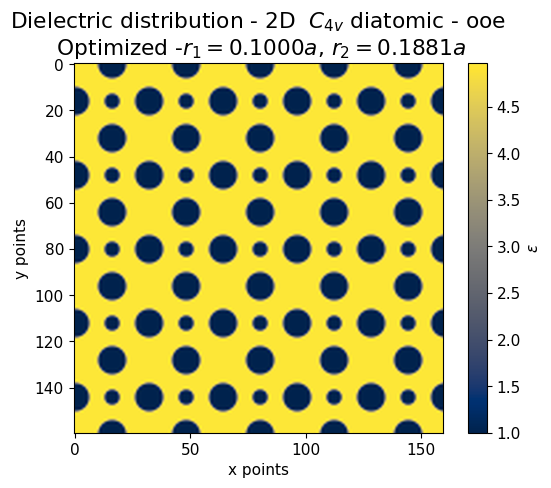

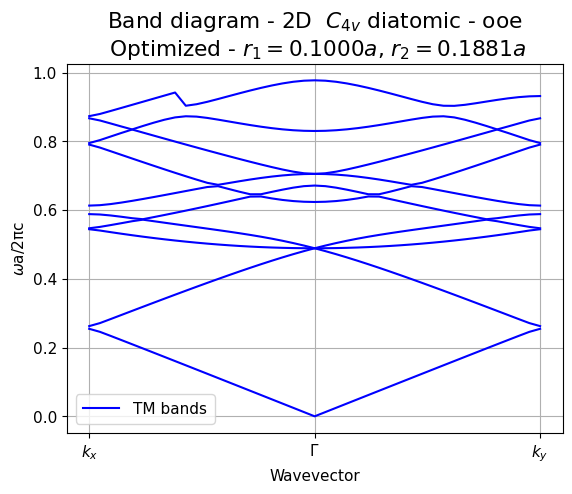

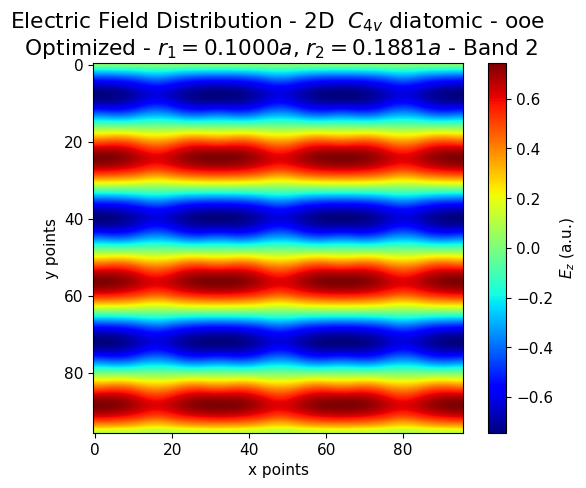

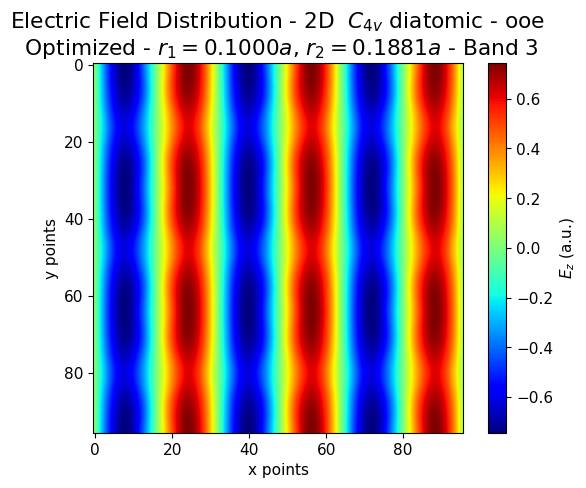

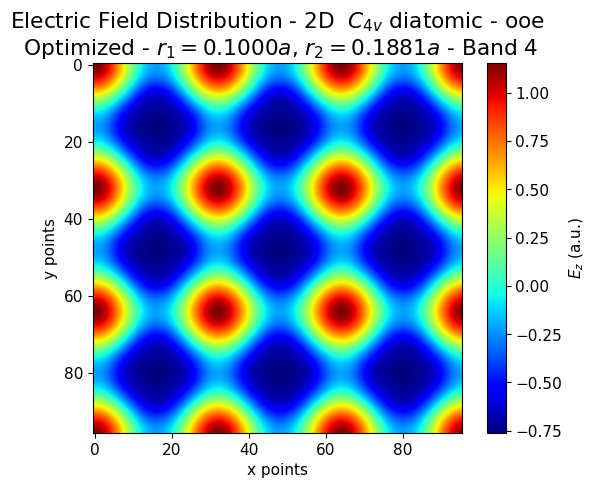

In [20]:
simulation_2D.run_hpc(mpb_command_line_params=dict(r1 = r1, r2 = r2), mpi = True)
print("2D simulation done")
viewer_2D = SimulationViewer(simulation_2D) 
opt = MPBDataOptions(rectify=True, periods= 5)
viewer_2D.figure()
viewer_2D.plot_epsilon_2d(conversion_options=opt)
plt.xlabel("x points")
plt.ylabel("y points")
data_line = f"$r_1={r1:.4f}a$, $r_2={r2:.4f}a$"
plt.title(f"Dielectric distribution - 2D  $C_{{4v}}$ diatomic - {crystal_orientation} \n Optimized -" + data_line)
viewer_2D.show()

# viewer_2D.plot_band_diagram("te", k_points_path=k_points, color = "red")
viewer_2D.plot_band_diagram("tm", k_points_path=k_points, color = "blue")
plt.ylabel("$\omega$a/2πc")

plt.title(f"Band diagram - 2D  $C_{{4v}}$ diatomic - {crystal_orientation}\n Optimized - " + data_line)
viewer_2D.show()

plt.figure()
c= viewer_2D.plot_field_2d(12, 2, "e", "z", "tm", False, np.real)
print(c)
plt.title(f"Electric Field Distribution - 2D  $C_{{4v}}$ diatomic - {crystal_orientation} \n Optimized - " + data_line + " - Band 2")
c.set_label("$E_{z}$ (a.u.)")
plt.xlabel("x points")
plt.ylabel("y points")
plt.show()

plt.figure() 
c=viewer_2D.plot_field_2d(12, 3, "e", "z", "tm", False, np.real)
plt.title(f"Electric Field Distribution - 2D  $C_{{4v}}$ diatomic - {crystal_orientation} \n Optimized - " + data_line + " - Band 3")
c.set_label("$E_{z}$ (a.u.)")
plt.xlabel("x points")
plt.ylabel("y points")
plt.show()


plt.figure()     
c=viewer_2D.plot_field_2d(12, 4, "e", "z", "tm", False, np.real)
plt.title(f"Electric Field Distribution - 2D  $C_{{4v}}$ diatomic - {crystal_orientation}\n Optimized - " + data_line + " - Band 4")
c.set_label("$E_{z}$ (a.u.)")
plt.xlabel("x points")  
plt.ylabel("y points")
plt.show()


In [34]:
df = simulation_2D.load_frequency_data("tm")

freq = simulation_2D.get_freq(df, 12, 3, "tm")
print("Frequency: ", freq)
a = freq*lam0
print(a)

Frequency:  0.488837
5.20122568e-07


# Slab
##  Unoptimized

2025-04-22 21:06:26,907 - INFO - Job submitted with ID: 24759577


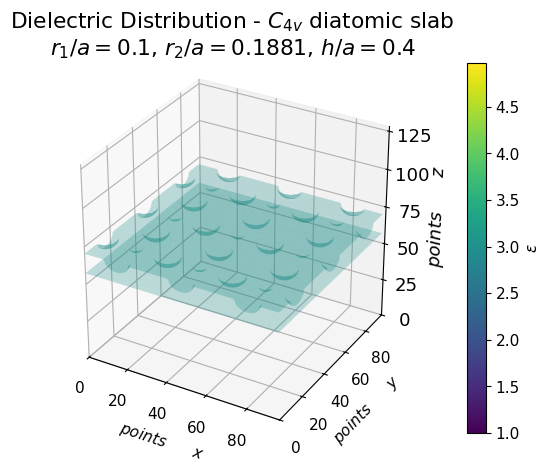

In [14]:

#lsf_config = LSFJobConfiguration(num_processors=4, span_option="hosts", span_value=1, queue="fotonano")
# import time
# time.sleep(1)

hh = 0.4
r1 = 0.1
r2 = 0.1881
simulation_slab.run_hpc_lsf(mpb_command_line_params=dict( h=hh, r1 = r1, r2 = r2,  cz_sphere=hh/2))
viewer_slab = SimulationViewer(simulation_slab) 
opt = MPBDataOptions(rectify=True, periods=(3,3,1))
viewer_slab.figure()
viewer_slab.plot_epsilon_3d(conversion_options=opt)

plt.title(f"Dielectric Distribution - $C_{{4v}}$ diatomic slab \n$r_1/a ={r1}$, $r_2/a = {r2}$, $h/a = {hh}$")
plt.xlabel("$points \qquad x$")
plt.ylabel("$points \qquad y$")
ax = plt.gca()
ax.set_zlabel("$points \qquad z$")
viewer_slab.show()
viewer_slab.simulation.extract_frequencies()


In [ ]:

viewer_slab.plot_band_diagram("", k_points_path=k_points, color = "red")
# plt.ylim(0.6,0.85)
plt.title(f"Band Diagram - $C_{{4v}}$ diatomic slab \n$r_1/a ={r1}$, $r_2/a = {r2}$, $h/a = {hh}$")
plt.ylabel("$\omega a/2\pi c$")
df = simulation_slab.load_frequency_data("")
viewer_slab.plot_light_cone(df)
viewer_slab.show()
df = simulation_slab.load_frequency_data("")
fr = simulation_slab._get_band_frequency(df, 2, "", 3) 

In [ ]:
df = simulation_slab.load_frequency_data("")
display(df)

In [ ]:
#viewer_2D.plot_band_diagram("tm", k_points_path=k_points, color = "blue")
kidx = 12
field = "e"
data_line_slab = f"$r_1/a ={r1}$, $r_2/a = {r2}$, $h/a = {hh}$"
for i in range(1, 31):
    plt.figure()
    c = viewer_slab.plot_field_2d(kidx, i, field, "z", "", False, np.real)
    plt.title("Electric Field Distribution - $C_{4v}$ diatomic slab - Optimized \n" + data_line_slab + f" - Band {i}")
    c.set_label("$E_{z}$ (a.u.)")
    plt.xlabel("x points")
    plt.ylabel("y points")
    ax = plt.gca()

    plt.show()




## Optimization

In [ ]:
print(simulation_slab_opt.script)

In [ ]:
import concurrent.futures
import time

# Assume 'name' and 'script_slab' are defined elsewhere
pop = numproc // 2
h_array = [0.4]

df_array= []
def run_optimization(h):
    opt_name = simulation_slab_opt.simulation_name + f"_p64_h_{h:0.3f}"
    optimizer = MPIdeOptimizator(
        simulation_name=opt_name,
        scheme_script=simulation_slab_opt.script,
        maxiter=15,
        param_names=["r1", "r2"],
        param_bounds=[(0.08, 0.12), (0.15, 0.25)],
        polarization="",
        de_options={"strategy": "rand1bin", "popsize": pop},
        bands=[18, 19, 20],
        height_slab=h,
        directory=os.path.join(data_rooth, opt_name)
    )
    # Submit the LSF job.
    try:
        optimizer.erease_data_file()
        pass
    except:
        pass
    optimizer.submit_lsf_job(lsf_config)
    try:
        data_file = optimizer.data_file
        analyzer = OptimizationDataAnalyzer(data_file)
        plt.figure()
        analyzer.plot_raw_data(plot_inverse_cost=True, points_only=True, use_logscale=True)        
        plt.savefig(f"{optimizer.simulation.directory}/{opt_name}_raw_data_log_point.png")
        plt.close()
        plt.figure()
        analyzer.plot_optimization_points_freq_dirac(points_only=True)
        plt.savefig(f"{optimizer.simulation.directory}/{opt_name}_freq_center.png")
        plt.close()

        df = analyzer.get_points_above_treshold(1200)
        df["h"] = h
        df_array.append(df)

    except Exception as e:
        print(f"An error occurred while analyzing the data: {e}")

# #Use ThreadPoolExecutor to run jobs concurrently with a small delay between job submissions.
# with concurrent.futures.ThreadPoolExecutor() as executor:
#     futures = []
#     for h in h_array:
#         futures.append(executor.submit(run_optimization, h))
#         time.sleep(1)  # Add a small delay between submissions
#     concurrent.futures.wait(futures)

In [ ]:
figure_ellipses = plt.figure()
figure_ellipses_no_point = plt.figure()
threshold = 1
h_array = [0.4]
plt.figure(figure_ellipses)
for h in h_array:
    try:
        h_norm = (h - min(h_array)) / (max(h_array) - min(h_array))
    except:
        h_norm = 1
    path_data_file = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_{h:0.3f}/{name_slab_opt}_p64_h_{h:0.3f}.de.data")
    analyzer = OptimizationDataAnalyzer(path_data_file)
    analyzer.plot_raw_data(plot_inverse_cost=True, points_only=True, use_logscale=True)
plt.title(f"Dirac Points Ellipses")
plt.legend()
plt.grid()
plt.xlabel("r1")
plt.ylabel("r2")
plt.show()






In [ ]:
path_data_file = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_0.350/{name_slab_opt}_p64_h_0.350.de.data")
analyzer = OptimizationDataAnalyzer(path_data_file)
points = analyzer.get_points_above_treshold(1000)
#display(points)
print(analyzer.compute_param2_from_param1_on_ellipse(0.23,branch="lower", threshold=1000))

In [ ]:
lambda0 = 1550
threshold = 1000

for i, h in enumerate(h_array):
    param2_delim = 0.25 if i >= 1 else 0.24
    param1_delim = 1    if i >= 1 else 0.24
    figure_freq_dirac, axes = plt.subplots(1, 2, figsize=(12, 6)) 
    plt.sca(axes[0])    
    path_data_opt = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_{h:0.3f}/{name_slab_opt}_p64_h_{h:0.3f}.de.data")
    analyzer = OptimizationDataAnalyzer(path_data_opt)
    x, y, f, aa = analyzer.compute_freq_dirac_along_ellipse(threshold=threshold)
    analyzer.plot_freq_dirac_along_ellipse(threshold=threshold)
    h_phy_array = [250, 275, 300, 325, 350,  375, 400, 425, 450]
    xlim = plt.xlim()
    ylim = plt.ylim()  
    for h_phy in h_phy_array:
        w_target = h_phy / lambda0/h
        if w_target < ylim[1]*1.1 and w_target > ylim[0]*0.9:   
            plt.plot(xlim, [w_target, w_target], label = f"$h_{{phy}} = {h_phy} nm$")
    plt.title(f"Dirac Points Frequencies at $h/a = {h}, T={T}K$")
    plt.legend()
    plt.grid()
    plt.xlabel("$r_1/a$")
    plt.ylabel("$\omega_{{D}}a/2\pi c$")
    colorbar = plt.colorbar() 
    colorbar.set_label("$r_2/a$")   



    plt.sca(axes[1])
    param1, param2, gradient, a= analyzer.compute_gradient_along_ellipse(threshold=threshold)
    mask = (param2 < param2_delim) & (param1 < param1_delim)
    param1_lower = param1[mask]
    param2_lower = param2[mask]
    gradient_lower = gradient[mask]
    idx_min = np.argmin(np.abs(gradient_lower))
    c = analyzer.plot_gradient_along_ellipse(threshold=threshold, abs = True)
    c.set_label("Dirac Frequency Gradient, absolute value, normalized")
    points = analyzer.get_points_above_treshold(threshold)
    # plt.scatter(points["r1"], points["r2"], c=1/points["cost"], cmap="viridis",
    #             norm=colors.LogNorm(vmin=(1/points["cost"]).min(), vmax=(1/points["cost"]).max()))
    plt.plot(param1_lower[idx_min], param2_lower[idx_min], "ro", label=f"Local Minimum, $r_1/a = {param1_lower[idx_min]:0.3f}$, $r_2/a = {param2_lower[idx_min]:0.3f}$")
    plt.title(f"Dirac Points Gradient at $h/a= {h}, T={T}K$")
    plt.legend(loc = "upper right")
    plt.xlabel("$r_1/a$")
    plt.ylabel("$r_2/a$")
    plt.grid()



    plt.sca(axes[0])
    f_lower = f[mask]   
    h_phy_target = f_lower[idx_min] * lambda0 * h
    plt.plot(xlim, [f_lower[idx_min], f_lower[idx_min]], "r--", label = f"$h_{{phy}} = {h_phy_target:0.0f}$ nm")
    plt.plot(param1_lower[idx_min], f_lower[idx_min], "ro", label = f"$r_1/a = {param1_lower[idx_min]:0.3f}$,\n $\omega_Da/2\pi c = {f_lower[idx_min]:0.3f}$")
    legend = plt.legend(loc = "upper right") if i == 0 else plt.legend(loc = "lower right")
    
 
    plt.show()





## Sweep  

In [9]:
r1 = 0.1
hh = 0.4
path_data_file = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_{hh:.3f}/{name_slab_opt}_p64_h_{hh:.3f}.de.data")
analyzer = OptimizationDataAnalyzer(path_data_file)
r2 = 0.188
print(r2)


0.188


In [10]:
# Instantiate the new sweeper
print("h:", hh, ", r1:", r1, ", r2:", r2)
from src.lsf_sweeper import LSFSweeper
values = np.linspace(0.11, 0.25, 30, endpoint=True)
sweeper = LSFSweeper(simulation_slab_sweep.simulation_name + "_r2", directory=simulation_slab_sweep.directory + "_r2",
                     scheme_script=simulation_slab_sweep.script, 
                        param_name="r2", param_values=values,
                        polarization="",
                        bands=[10, 11, 12, 13, 14, 15, 16, 17, 18,19,20, 21, 22],
                        others_command_line_params={"r1": r1, "h": hh},
                       )

#Run the sweeper
# sweeper.submit_lsf_job(lsf_config)

h: 0.4 , r1: 0.1 , r2: 0.188


,r2,r1,h,band_11,band_12,band_13,band_14,band_15,band_16,band_17,band_18,band_19,band_20,band_21,band_22
0,0.110000,0.1,0.4,0.546999,0.547018,0.548767,0.548770,0.650127,0.650131,0.658300,0.659154,0.660326,0.660327,0.680730,0.680730
1,0.114828,0.1,0.4,0.547026,0.547055,0.549073,0.549075,0.650301,0.650304,0.658345,0.659469,0.660668,0.660669,0.680731,0.680732
2,0.119655,0.1,0.4,0.547069,0.547114,0.549458,0.549459,0.650523,0.650526,0.658416,0.659928,0.661119,0.661125,0.680735,0.680735
3,0.124483,0.1,0.4,0.547111,0.547175,0.549861,0.549865,0.650739,0.650745,0.658482,0.660405,0.661544,0.661547,0.680739,0.680739
4,0.129310,0.1,0.4,0.547167,0.547254,0.550315,0.550318,0.650983,0.650988,0.658573,0.660942,0.662029,0.662032,0.680744,0.680744
5,0.134138,0.1,0.4,0.547231,0.547337,0.550787,0.550790,0.651226,0.651231,0.658675,0.661540,0.662503,0.662503,0.680749,0.680749
6,0.138966,0.1,0.4,0.547309,0.547440,0.551308,0.551309,0.651491,0.651496,0.658789,0.662207,0.663007,0.663011,0.680756,0.680756
7,0.143793,0.1,0.4,0.547412,0.547591,0.551918,0.551924,0.651813,0.651821,0.658955,0.662961,0.663649,0.663660,0.680765,0.680765
8,0.148621,0.1,0.4,0.547531,0.547758,0.552554,0.552557,0.652134,0.652140,0.659115,0.663875,0.664271,0.664277,0.680776,0.680776
9,0.153448,0.1,0.4,0.547669,0.547942,0.553232,0.553235,0.652467,0.652472,0.659315,0.664869,0.664933,0.664940,0.680790,0.680790


0.1 0.188


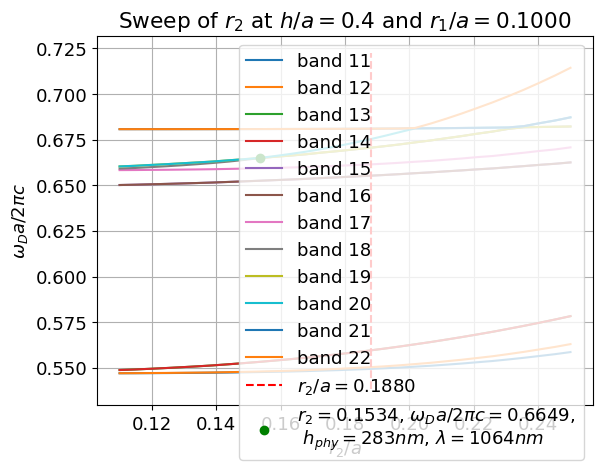

a [nm]:  707.488712
r1 [a]:  0.1 r2:  0.1534482758620689
r1 [nm]:  70.7488712 r2 [nm]:  108.56292304827582
h [nm]:  282.9954848


In [11]:
df = sweeper.load_results()
display(df)
print(r1,r2)
plt.figure()
bands = [ 11, 12, 13, 14, 15, 16, 17, 18,19,20, 21, 22]
for i in bands:
    plt.plot(df["r2"], df[f"band_{i}"], label=f"band {i}")
lam0 = 1064e-9
c0 = 299792458

plt.grid()
plt.xlabel("$r_2/a$")
plt.ylabel("$\omega_Da/2\pi c$")
ylim = plt.ylim()
plt.plot([r2, r2], ylim, "r--", label = f"$r_2/a = {r2:0.4f}$")
idx_freq_dirac = np.argmin(np.abs(df["band_20"] - df["band_18"]))
freq_dirac_mpb = df["band_19"][idx_freq_dirac]  
a_phy = freq_dirac_mpb * lam0   
h_phy = a_phy * hh
r2_phy = df["r2"][idx_freq_dirac] * a_phy
r1_phy = r1 * a_phy
plt.plot(df["r2"][idx_freq_dirac], df["band_19"][idx_freq_dirac], "go", label = f"$r_2 ={r2_phy/a_phy:0.4f}$, $\omega_Da/2\pi c = {freq_dirac_mpb:0.4f}$, \n $h_{{phy}} =  {h_phy/1e-9:.0f} nm$, $\lambda = {lam0/1e-9:0.0f} nm$") 
plt.title(f"Sweep of $r_2$ at $h/a = {hh}$ and $r_1/a = {r1:0.4f}$")
plt.legend()
plt.savefig(f"sweep_r2_h_0.35_r1_{r1:0.4f}.png")
plt.show()

r2 = df["r2"][idx_freq_dirac]
print("a [nm]: ", a_phy/1e-9)
print("r1 [a]: ", r1, "r2: ", r2)
print("r1 [nm]: ", r1_phy/1e-9, "r2 [nm]: ", r2_phy/1e-9)
print("h [nm]: ", h_phy/1e-9) 

c0 = 299792458


## Optimized

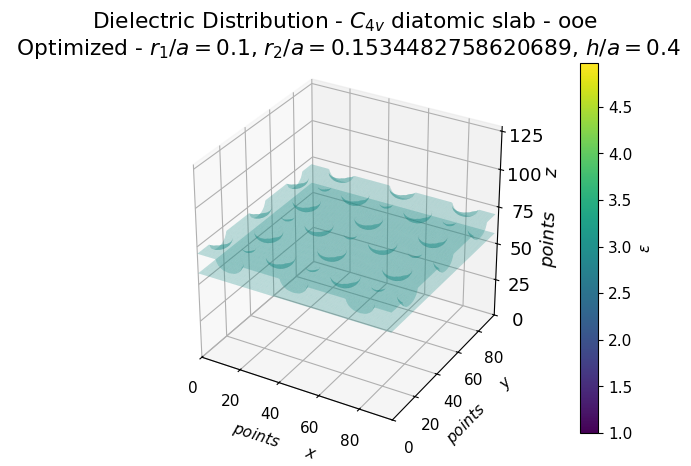

,k index,k1,k2,k3,kmag/2pi,band 1,band 2,band 3,band 4,band 5,...,band 21,band 22,band 23,band 24,band 25,band 26,band 27,band 28,band 29,band 30
0,1,0.100000,0.000000,0,0.100000,0.084718,0.096004,0.215747,0.221506,0.263192,...,0.688506,0.716830,0.722962,0.726656,0.780008,0.780838,0.809667,0.815142,0.828883,0.840869
1,2,0.090909,0.000000,0,0.090909,0.077223,0.087304,0.212776,0.217671,0.260467,...,0.687377,0.719360,0.723175,0.725442,0.777411,0.778233,0.813076,0.817317,0.830986,0.840493
2,3,0.081818,0.000000,0,0.081818,0.069668,0.078597,0.210074,0.214141,0.257976,...,0.686350,0.719931,0.721898,0.727760,0.774781,0.775623,0.816261,0.819643,0.833074,0.840171
3,4,0.072727,0.000000,0,0.072727,0.062060,0.069882,0.207644,0.210933,0.255725,...,0.685427,0.716707,0.724434,0.730142,0.772145,0.773020,0.819174,0.822115,0.835125,0.839909
4,5,0.063636,0.000000,0,0.063636,0.054404,0.061160,0.205491,0.208061,0.253722,...,0.684610,0.713569,0.726952,0.732536,0.769526,0.770433,0.821819,0.824672,0.837117,0.839718
5,6,0.054545,0.000000,0,0.054545,0.046707,0.052433,0.203617,0.205539,0.251973,...,0.683902,0.710556,0.729434,0.734929,0.766950,0.767873,0.824258,0.827180,0.839019,0.839612
6,7,0.045455,0.000000,0,0.045455,0.038975,0.043702,0.202025,0.203381,0.250482,...,0.683302,0.707715,0.731850,0.737301,0.764448,0.765359,0.826549,0.829489,0.839613,0.840794
7,8,0.036364,0.000000,0,0.036364,0.031214,0.034966,0.200719,0.201597,0.249256,...,0.682817,0.705117,0.734156,0.739627,0.762070,0.762917,0.828705,0.831465,0.839747,0.842394
8,9,0.027273,0.000000,0,0.027273,0.023431,0.026227,0.199700,0.200199,0.248297,...,0.682438,0.702860,0.736272,0.741852,0.759896,0.760601,0.830678,0.833017,0.840020,0.843758
9,10,0.018182,0.000000,0,0.018182,0.015630,0.017486,0.198971,0.199195,0.247610,...,0.682167,0.701074,0.738066,0.743863,0.758060,0.758525,0.832329,0.834140,0.840379,0.844813


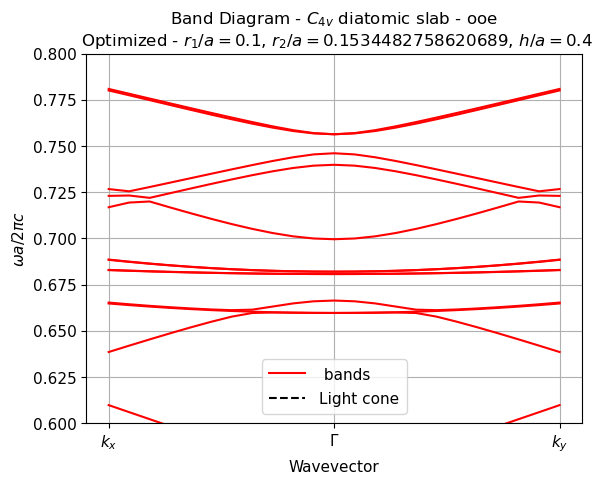

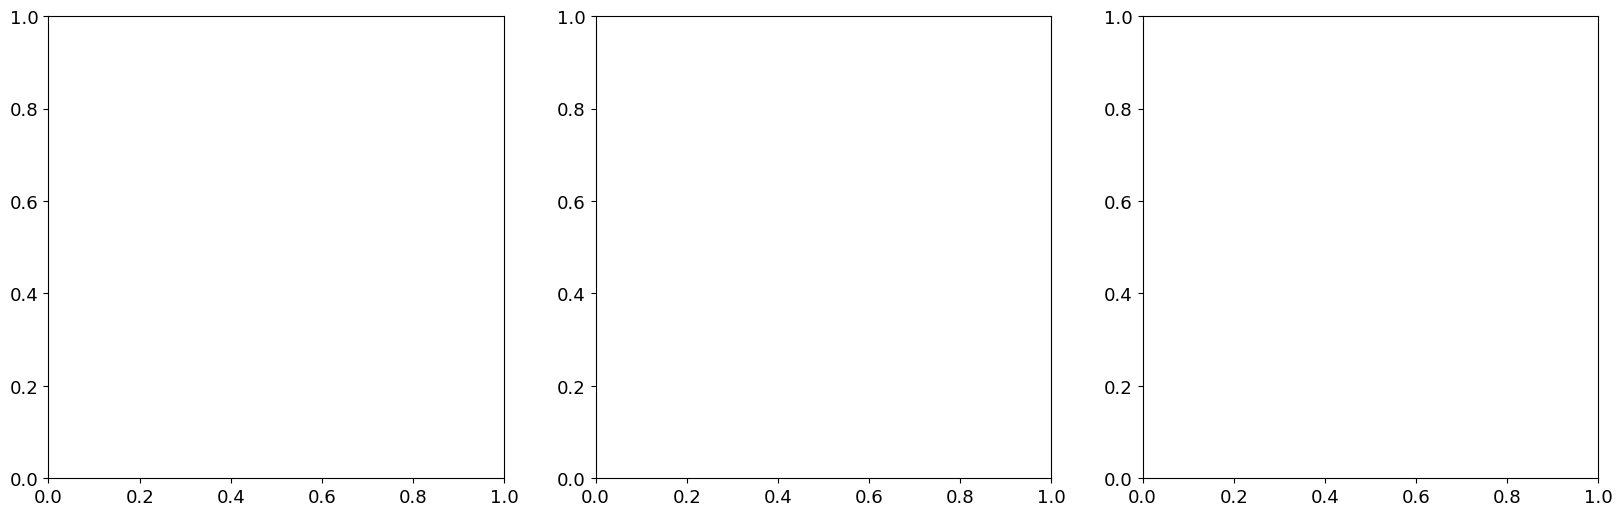

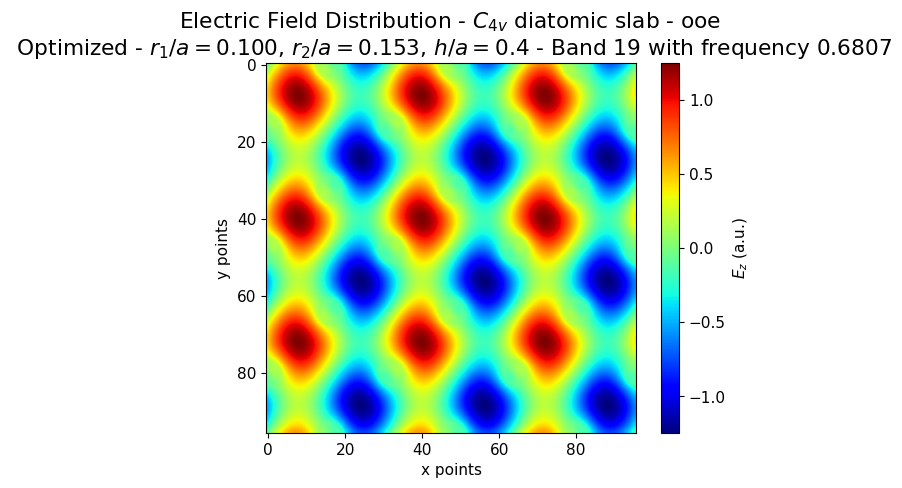

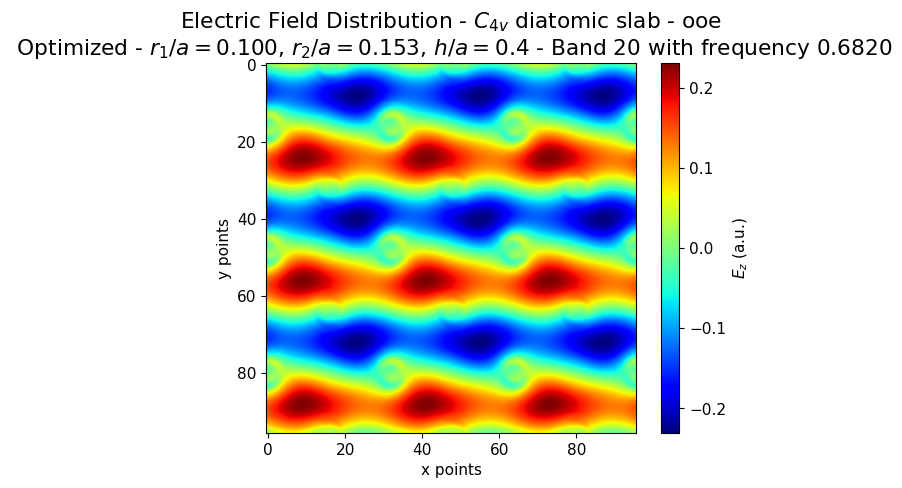

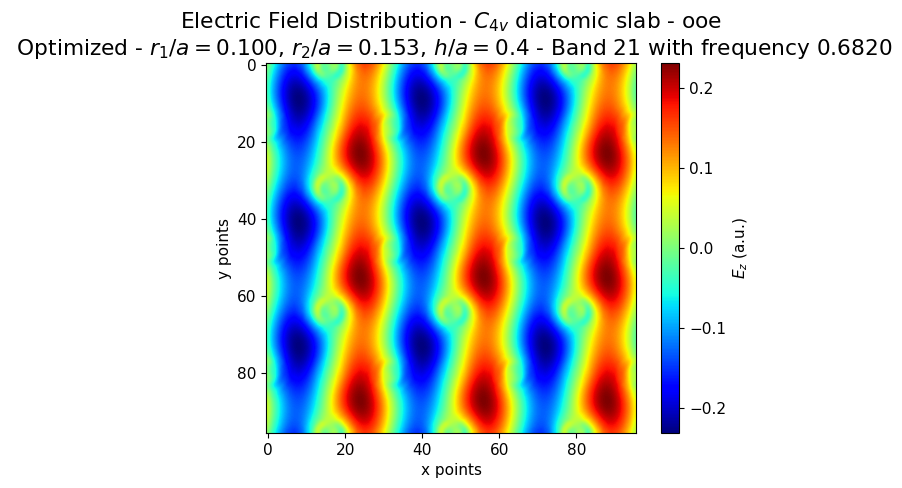

In [ ]:

#lsf_config = LSFJobConfiguration(num_processors=4, span_option="hosts", span_value=1, queue="fotonano")
# import time
# time.sleep(1)
hh = 0.4
r1 = 0.1
r2 = 0.2
simulation_slab.run_hpc_lsf(mpb_command_line_params=dict(r1 = r1, r2 = 0.2, h=hh, cz_sphere=hh/2))
viewer_slab = SimulationViewer(simulation_slab) 
opt = MPBDataOptions(rectify=True, periods=(3,3,1))
viewer_slab.figure()
viewer_slab.plot_epsilon_3d(conversion_options=opt)
plt.title(f"Dielectric Distribution - $C_{{4v}}$ diatomic slab - {crystal_orientation} \n Optimized - $r_1/a ={r1}$, $r_2/a = {r2}$, $h/a = {hh}$")
plt.xlabel("$points \qquad x$")
plt.ylabel("$points \qquad y$")
ax = plt.gca()
ax.set_zlabel("$points \qquad z$")
viewer_slab.show()
viewer_slab.simulation.extract_frequencies()
viewer_slab.plot_band_diagram("", k_points_path=k_points, color = "red")

#viewer_2D.plot_band_diagram("tm", k_points_path=k_points, color = "blue")
plt.title(f"Band Diagram - $C_{{4v}}$ diatomic slab - {crystal_orientation} \n Optimized - $r_1/a ={r1}$, $r_2/a = {r2}$, $h/a = {hh}$")
plt.ylabel("$\omega a/2\pi c$")
df = simulation_slab.load_frequency_data("")
display(df)
viewer_slab.plot_light_cone(df)
plt.ylim(0.6, 0.8)
viewer_slab.show()
figure, axes = plt.subplots(1, 3, figsize=(20, 6))

data_line_slab = f"$r_1/a ={r1:.3f}$, $r_2/a = {r2:.3f}$, $h/a = {hh}$"

kidx = 12

for bands in [19, 20, 21]:
    plt.figure()
    c = viewer_slab.plot_field_2d(kidx, bands, "e", "z", "", False, np.real)
    fq = simulation_slab.get_freq(df, kidx, bands, "")
    plt.title(f"Electric Field Distribution - $C_{{4v}}$ diatomic slab - {crystal_orientation} \n Optimized - " + data_line_slab + f" - Band {bands} with frequency {fq:.4f}")


    c.set_label("$E_{z}$ (a.u.)")
    plt.xlabel("x points")
    plt.ylabel("y points")
    ax = plt.gca()
    plt.show()

